### Boston Housing Price Prediction

In [115]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


#### Load Dataset

The difference is:

- `r'..\dataset\housing.data'` is a **raw string** in Python. The `r` prefix tells Python not to treat backslashes (`\`) as escape characters. So `\n` is just a backslash and an 'n', not a newline.
- `'../dataset/housing.data'` is a **normal string** with forward slashes, which do not need escaping.

You need to use `r` when your path contains backslashes (common in Windows paths), to avoid accidental escape sequences. For example, `'\n'` is a newline, but `r'\n'` is a backslash and an 'n'.

In summary:
- Use `r'...'` for Windows-style paths with backslashes.
- Use `'...'` for Unix-style paths with forward slashes (no need for `r`).

In [116]:
data = pd.read_csv('../dataset/housing.data', header=None, delim_whitespace=True)
# data = pd.read_csv(r'..\dataset\BostonHousing.csv')

C:\Users\91967\AppData\Local\Temp\ipykernel_4660\6270686.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('../dataset/housing.data', header=None, delim_whitespace=True)


In [117]:
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.006,18.000,2.310,0,0.538,6.575,65.200,4.090,1,296.000,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0,0.469,6.421,78.900,4.967,2,242.000,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0,0.469,7.185,61.100,4.967,2,242.000,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0,0.458,6.998,45.800,6.062,3,222.000,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0,0.458,7.147,54.200,6.062,3,222.000,18.700,396.900,5.330,36.200


In [118]:
col_name = ['CRIM', 'ZN' , 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 
'PTRATIO', 'B', 'LSTAT', 'MEDV']
data.columns = col_name


In [119]:
col_def = {
    'CRIM': 'per capita crime rate by town',
    'ZN': 'proportion of residential land zoned for lots over 25,000 sq.ft.',
    'INDUS': 'proportion of non-retail business acres per town',
    'CHAS': 'Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)',
    'NOX': 'nitric oxides concentration (parts per 10 million)',
    'RM': 'average number of rooms per dwelling',
    'AGE': 'proportion of owner-occupied units built prior to 1940',
    'DIS': 'weighted distances to five Boston employment centres',
    'RAD': 'index of accessibility to radial highways',
    'TAX': 'full-value property-tax rate per $10,000',
    'PTRATIO': 'pupil-teacher ratio by town',
    'B': '1000(Bk - 0.63)^2 where Bk is the proportion of black residents by town',
    'LSTAT': '% lower status of the population',
    'MEDV': 'Median value of owner-occupied homes in $1000s'
}
for col, desc in col_def.items():
    print(f"{col}: {desc}")

CRIM: per capita crime rate by town
ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS: proportion of non-retail business acres per town
CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX: nitric oxides concentration (parts per 10 million)
RM: average number of rooms per dwelling
AGE: proportion of owner-occupied units built prior to 1940
DIS: weighted distances to five Boston employment centres
RAD: index of accessibility to radial highways
TAX: full-value property-tax rate per $10,000
PTRATIO: pupil-teacher ratio by town
B: 1000(Bk - 0.63)^2 where Bk is the proportion of black residents by town
LSTAT: % lower status of the population
MEDV: Median value of owner-occupied homes in $1000s


In [120]:
data.sample(6)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
191,0.069,45.000,3.440,0,0.437,6.739,30.800,6.480,5,398.000,15.200,389.710,4.690,30.500
267,0.578,20.000,3.970,0,0.575,8.297,67.000,2.422,5,264.000,13.000,384.540,7.440,50.000
397,7.672,0.000,18.100,0,0.693,5.747,98.900,1.633,24,666.000,20.200,393.100,19.920,8.500
450,6.718,0.000,18.100,0,0.713,6.749,92.600,2.324,24,666.000,20.200,0.320,17.440,13.400
444,12.802,0.000,18.100,0,0.740,5.854,96.600,1.896,24,666.000,20.200,240.520,23.790,10.800
92,0.042,28.000,15.040,0,0.464,6.442,53.600,3.666,4,270.000,18.200,395.010,8.160,22.900


#### Exploratory Data Anaysis (EDA)

In [121]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000
mean,3.614,11.364,11.137,0.069,0.555,6.285,68.575,3.795,9.549,408.237,18.456,356.674,12.653,22.533
std,8.602,23.322,6.860,0.254,0.116,0.703,28.149,2.106,8.707,168.537,2.165,91.295,7.141,9.197
min,0.006,0.000,0.460,0.000,0.385,3.561,2.900,1.130,1.000,187.000,12.600,0.320,1.730,5.000
25%,0.082,0.000,5.190,0.000,0.449,5.885,45.025,2.100,4.000,279.000,17.400,375.377,6.950,17.025
50%,0.257,0.000,9.690,0.000,0.538,6.208,77.500,3.207,5.000,330.000,19.050,391.440,11.360,21.200
75%,3.677,12.500,18.100,0.000,0.624,6.623,94.075,5.188,24.000,666.000,20.200,396.225,16.955,25.000
max,88.976,100.000,27.740,1.000,0.871,8.780,100.000,12.127,24.000,711.000,22.000,396.900,37.970,50.000


In [122]:
col_study = ['CRIM','ZN','RM', 'MEDV']
data_study = data[col_study]

<Figure size 1000x600 with 0 Axes>

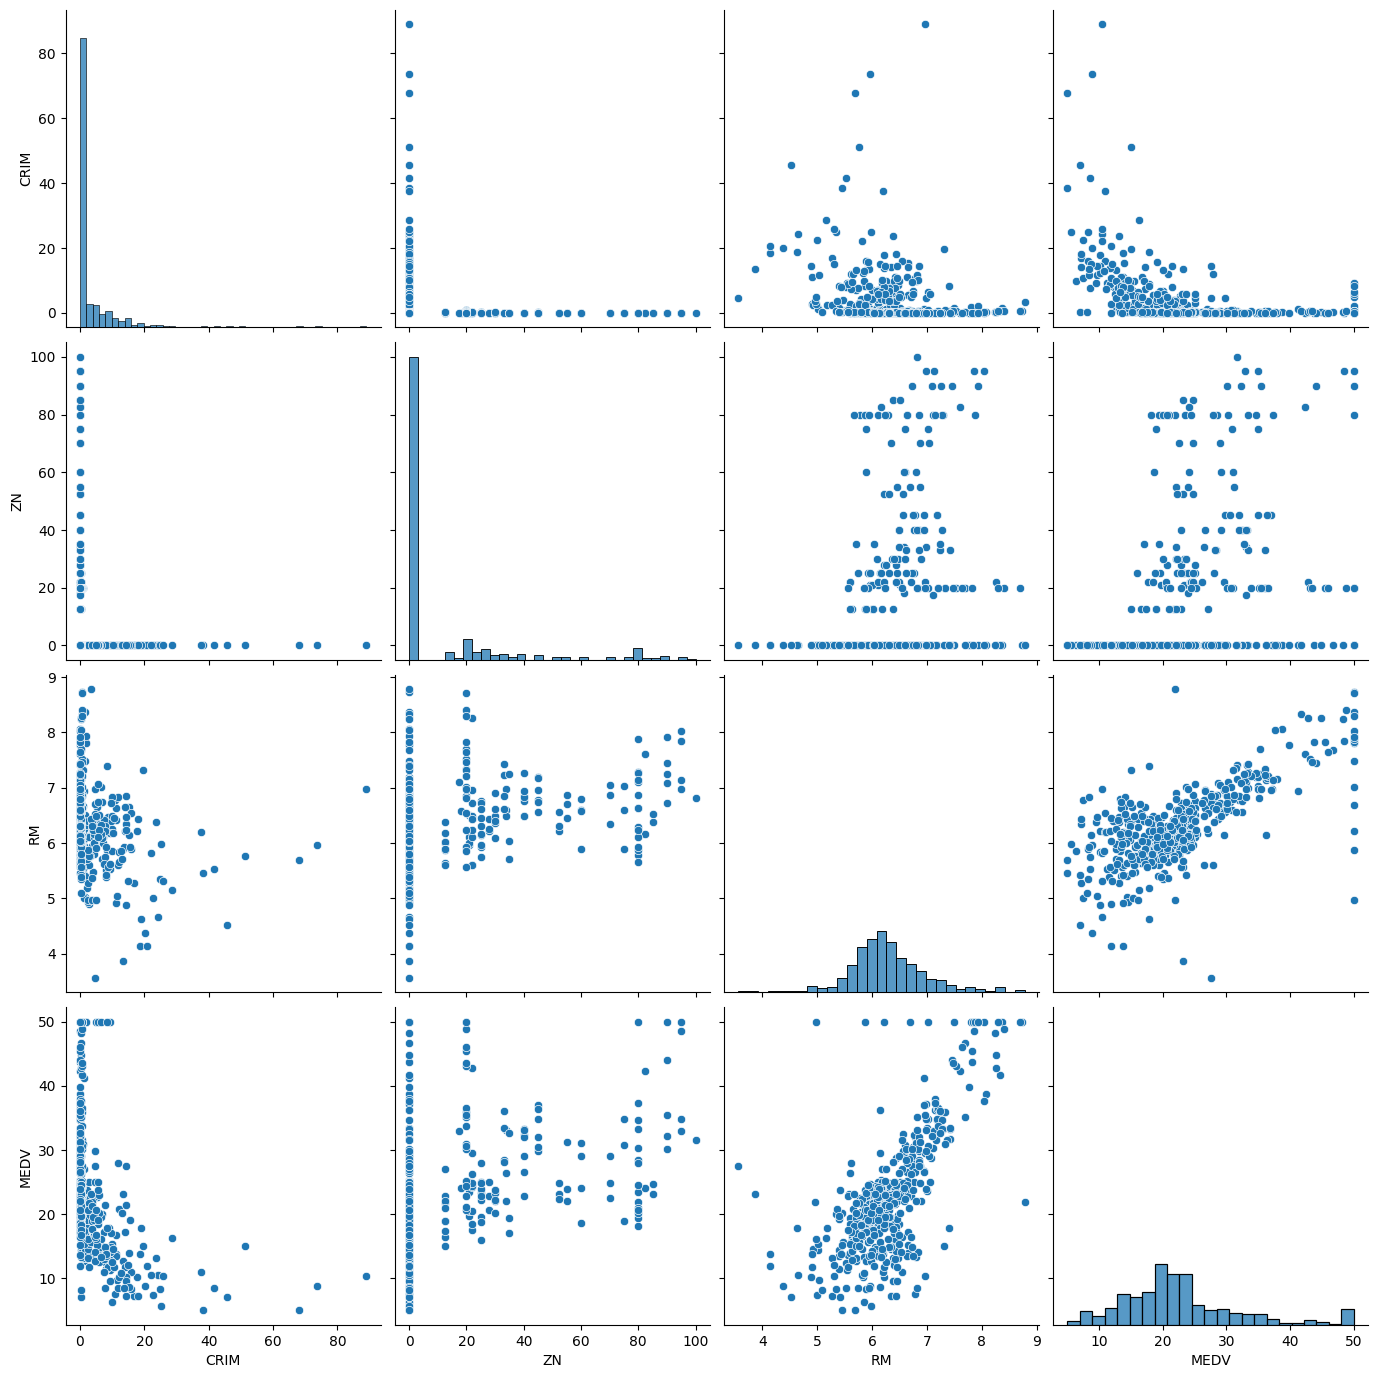

In [123]:
plt.figure(figsize=(10, 6))
sns.pairplot(data_study, height=3.5)
plt.show()

<Figure size 1000x600 with 0 Axes>

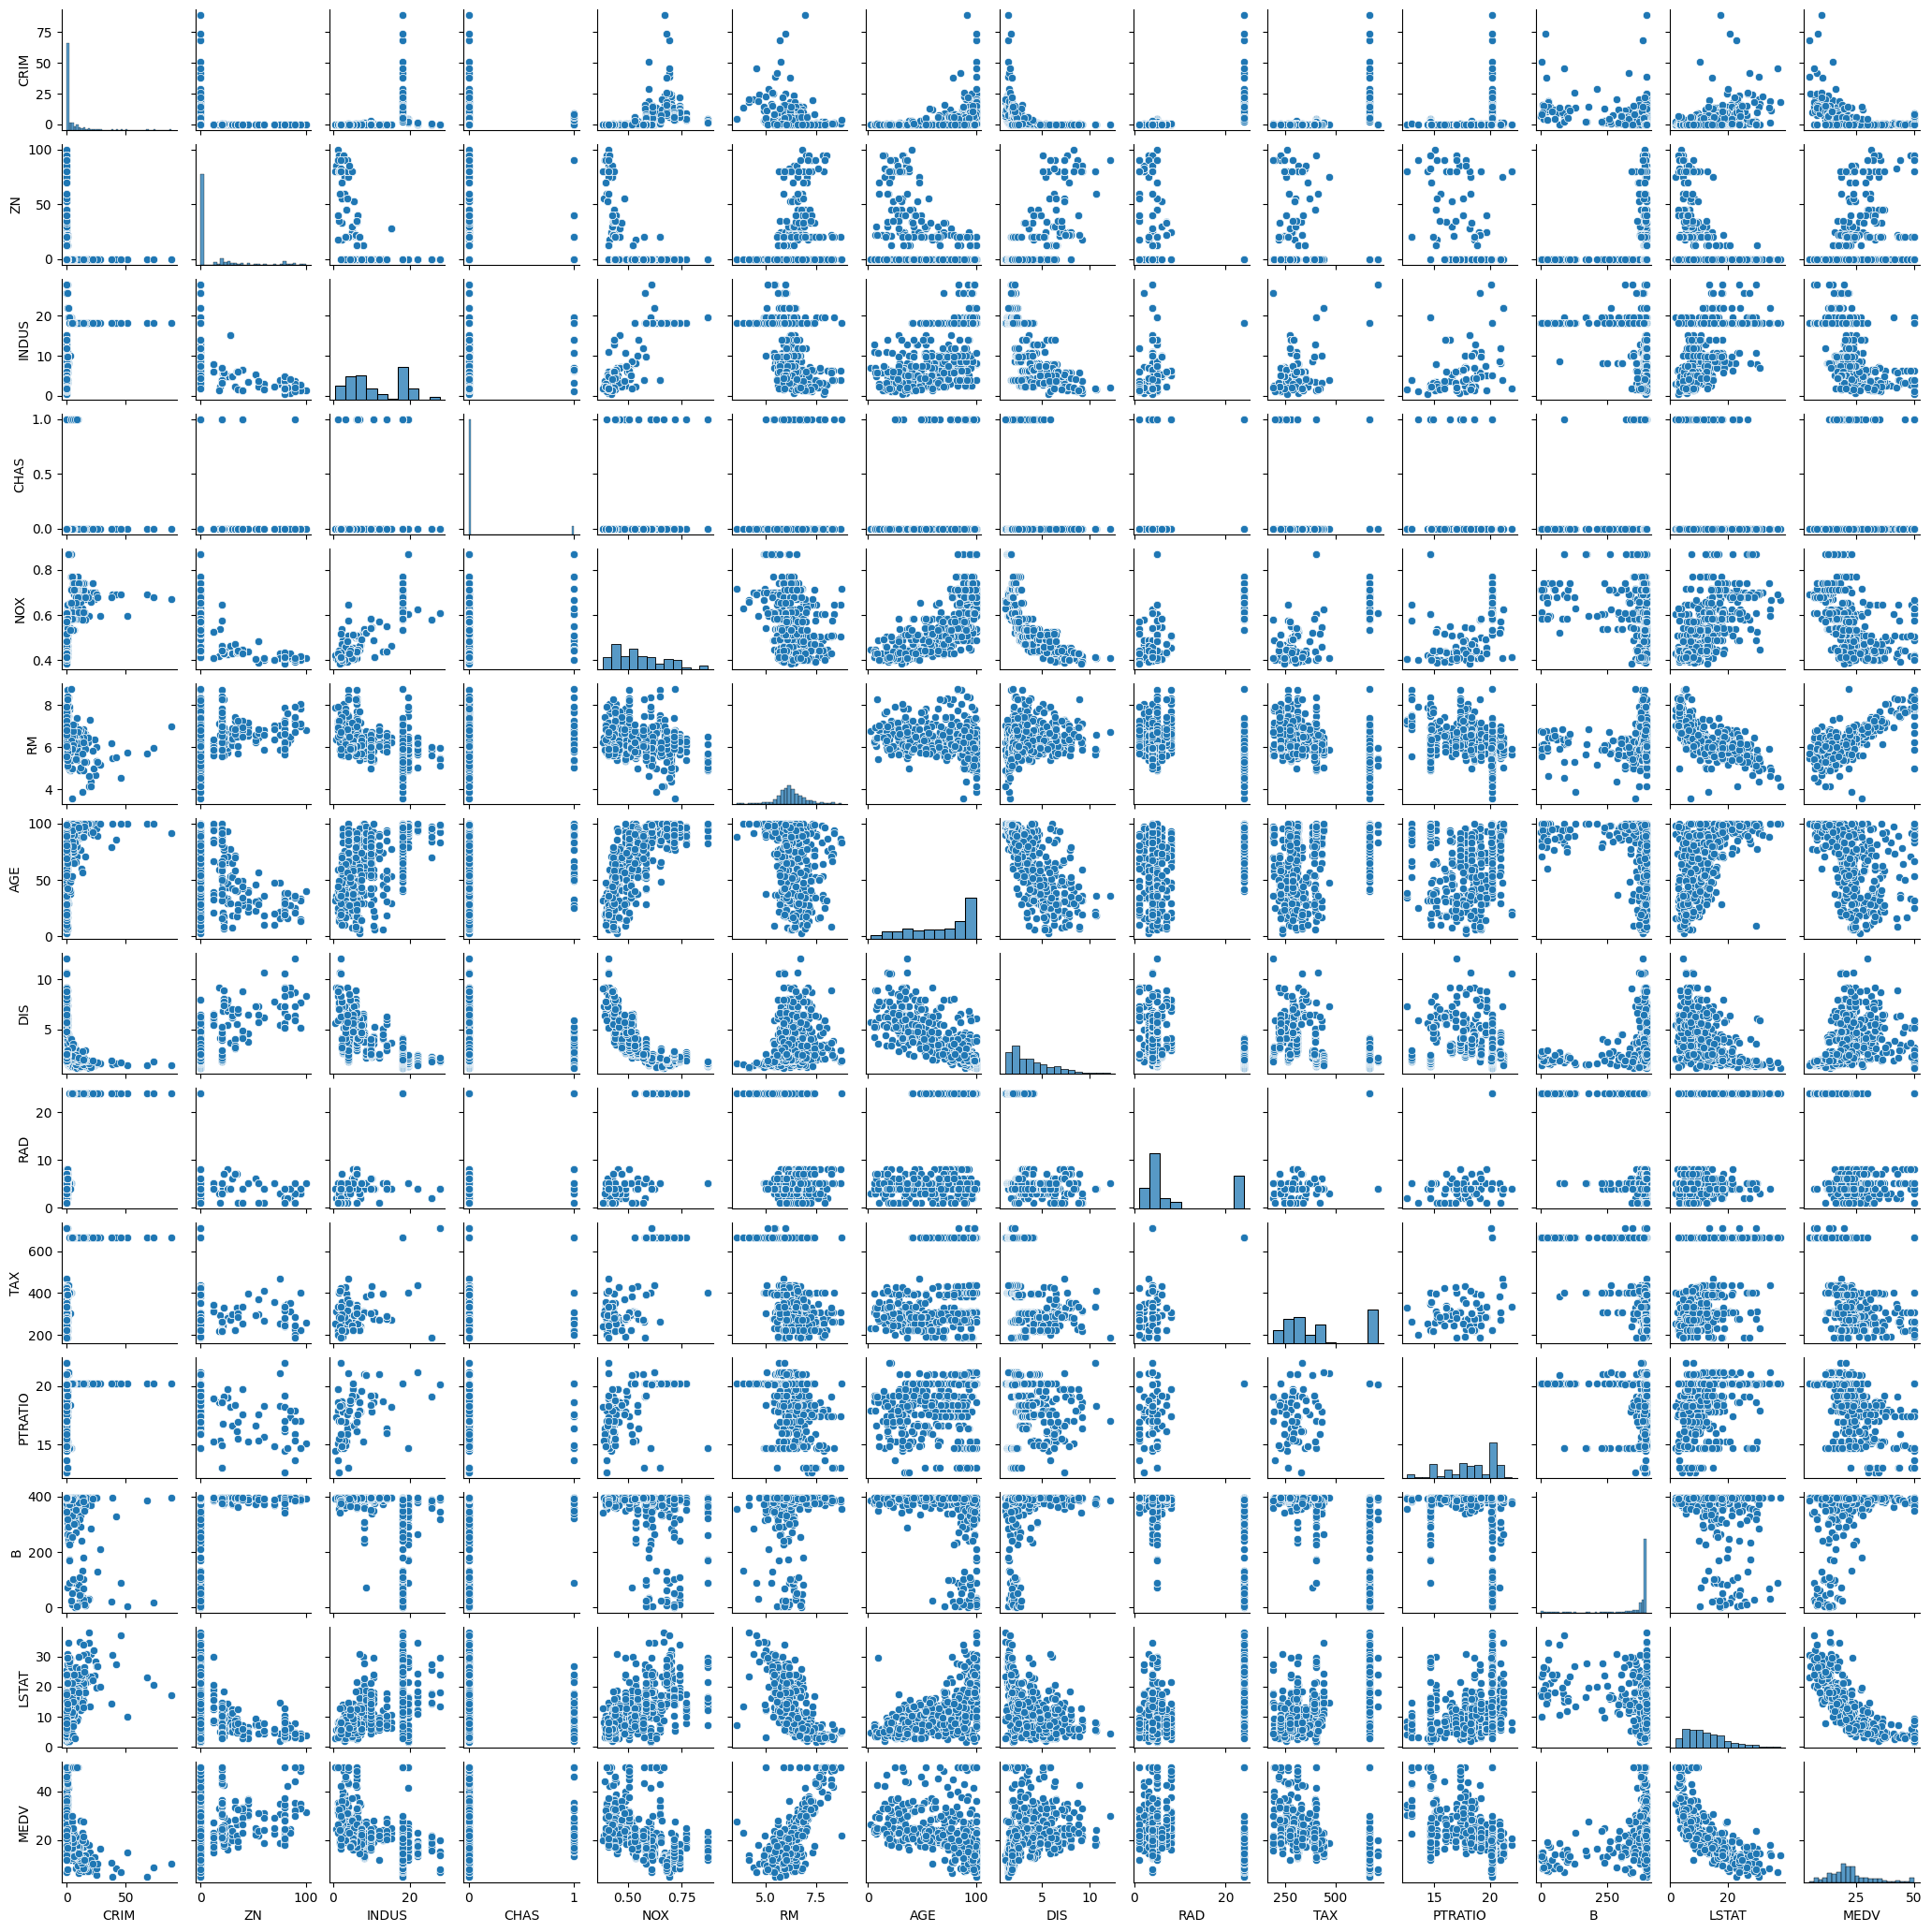

In [124]:
plt.figure(figsize=(10, 6))
sns.pairplot(data, height=1.5)
plt.show()

### Correlation analysis and Feature selection

In [125]:
pd.options.display.float_format = '{:,.3f}'.format

In [126]:
data.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000,-0.200,0.407,-0.056,0.421,-0.219,0.353,-0.380,0.626,0.583,0.290,-0.385,0.456,-0.388
ZN,-0.200,1.000,-0.534,-0.043,-0.517,0.312,-0.570,0.664,-0.312,-0.315,-0.392,0.176,-0.413,0.360
INDUS,0.407,-0.534,1.000,0.063,0.764,-0.392,0.645,-0.708,0.595,0.721,0.383,-0.357,0.604,-0.484
CHAS,-0.056,-0.043,0.063,1.000,0.091,0.091,0.087,-0.099,-0.007,-0.036,-0.122,0.049,-0.054,0.175
NOX,0.421,-0.517,0.764,0.091,1.000,-0.302,0.731,-0.769,0.611,0.668,0.189,-0.380,0.591,-0.427
RM,-0.219,0.312,-0.392,0.091,-0.302,1.000,-0.240,0.205,-0.210,-0.292,-0.356,0.128,-0.614,0.695
AGE,0.353,-0.570,0.645,0.087,0.731,-0.240,1.000,-0.748,0.456,0.506,0.262,-0.274,0.602,-0.377
DIS,-0.380,0.664,-0.708,-0.099,-0.769,0.205,-0.748,1.000,-0.495,-0.534,-0.232,0.292,-0.497,0.250
RAD,0.626,-0.312,0.595,-0.007,0.611,-0.210,0.456,-0.495,1.000,0.910,0.465,-0.444,0.489,-0.382
TAX,0.583,-0.315,0.721,-0.036,0.668,-0.292,0.506,-0.534,0.910,1.000,0.461,-0.442,0.544,-0.469


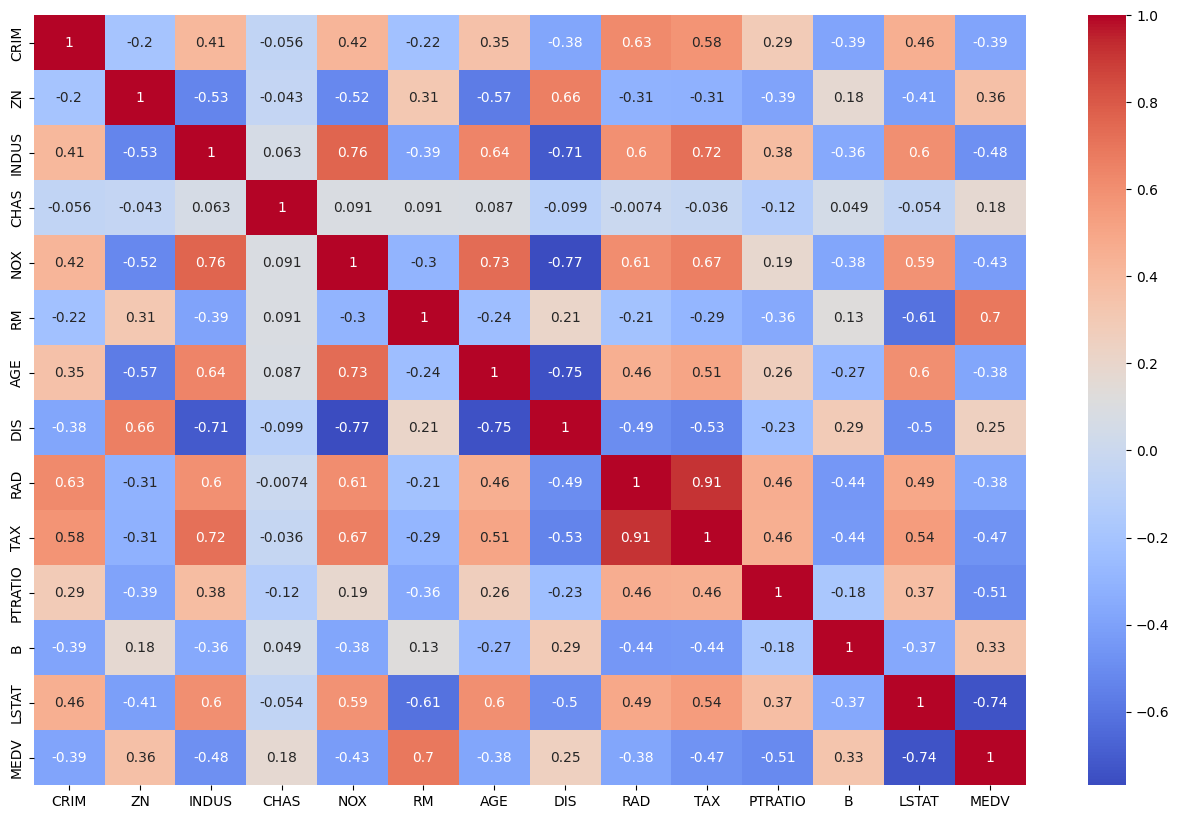

In [127]:
plt.figure(figsize=(16, 10))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

### Simple Linear Regression with Room number (RM) and Price of House(MEDV)

In [128]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006,18.000,2.310,0,0.538,6.575,65.200,4.090,1,296.000,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0,0.469,6.421,78.900,4.967,2,242.000,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0,0.469,7.185,61.100,4.967,2,242.000,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0,0.458,6.998,45.800,6.062,3,222.000,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0,0.458,7.147,54.200,6.062,3,222.000,18.700,396.900,5.330,36.200


In [129]:
X = data[['RM']]
y = data['MEDV']

In [130]:
from sklearn.linear_model import LinearRegression

In [131]:
LR = LinearRegression()
LR.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [132]:
print(f'Intercept: {LR.intercept_}')
print(f'Coefficient: {LR.coef_}')

Intercept: -34.670620776438554
Coefficient: [9.10210898]


In [133]:
y_pred_ = LR.coef_[0] * X.values + LR.intercept_

In [134]:
# y_pred_ = y_pred_.flatten()
y_pred_ = y_pred_.reshape(-1)
y_pred_

array([25.17574577, 23.77402099, 30.72803225, 29.02593787, 30.38215211,
       23.85593997, 20.05125842, 21.50759586, 16.5833549 , 19.97844155,
       23.3735282 , 20.02395209, 18.93169901, 19.47782555, 20.81583557,
       18.43108302, 19.35039603, 19.85101202, 14.99048582, 17.45715736,
       16.02812625, 19.6234593 , 21.23453259, 18.23993873, 19.25027283,
       16.29208741, 18.23993873, 20.36983223, 24.44757706, 26.07685456,
       17.32972783, 20.59738496, 19.48692766, 17.22050253, 20.81583557,
       19.33219181, 18.49479778, 18.57671676, 19.63256141, 25.35778795,
       29.26259271, 26.95065703, 21.48028953, 21.86257811, 20.57007863,
       17.04756245, 17.99418179, 20.21509638, 14.47166561, 16.31939374,
       19.60525508, 20.98877564, 24.5932108 , 19.92382889, 18.9225969 ,
       31.31056723, 23.42814085, 27.36935404, 21.26183891, 19.27757916,
       17.58458688, 19.63256141, 24.09259481, 26.87784015, 29.99076143,
       22.58164472, 18.0032839 , 18.83157581, 16.24657686, 18.89

In [135]:
y_pred = LR.predict(X)

In [136]:
y_pred

array([25.17574577, 23.77402099, 30.72803225, 29.02593787, 30.38215211,
       23.85593997, 20.05125842, 21.50759586, 16.5833549 , 19.97844155,
       23.3735282 , 20.02395209, 18.93169901, 19.47782555, 20.81583557,
       18.43108302, 19.35039603, 19.85101202, 14.99048582, 17.45715736,
       16.02812625, 19.6234593 , 21.23453259, 18.23993873, 19.25027283,
       16.29208741, 18.23993873, 20.36983223, 24.44757706, 26.07685456,
       17.32972783, 20.59738496, 19.48692766, 17.22050253, 20.81583557,
       19.33219181, 18.49479778, 18.57671676, 19.63256141, 25.35778795,
       29.26259271, 26.95065703, 21.48028953, 21.86257811, 20.57007863,
       17.04756245, 17.99418179, 20.21509638, 14.47166561, 16.31939374,
       19.60525508, 20.98877564, 24.5932108 , 19.92382889, 18.9225969 ,
       31.31056723, 23.42814085, 27.36935404, 21.26183891, 19.27757916,
       17.58458688, 19.63256141, 24.09259481, 26.87784015, 29.99076143,
       22.58164472, 18.0032839 , 18.83157581, 16.24657686, 18.89

### Plot the model

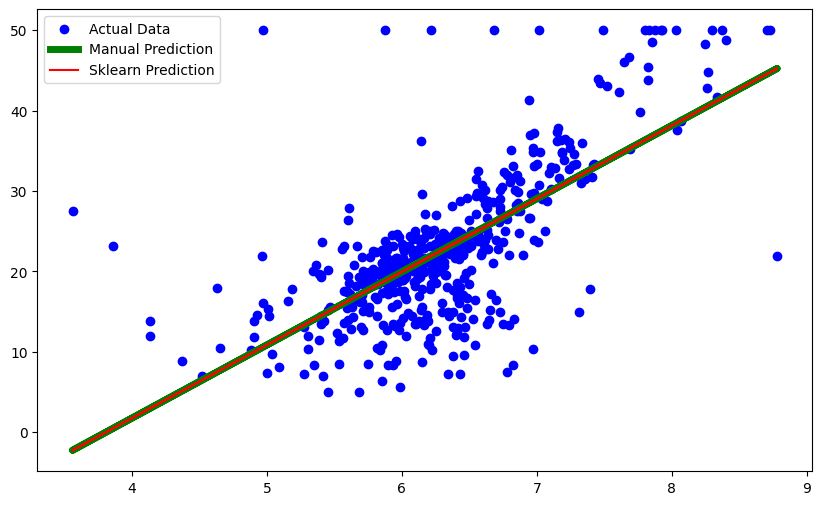

In [137]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred_, color='green', linewidth=5, label='Manual Prediction')
plt.plot(X, y_pred, color='red', label='Sklearn Prediction')
plt.legend()
plt.show()

In [138]:
rm = pd.DataFrame({'RM': [5]})
LR.predict(rm)

array([10.83992413])

### Robust Regression
* RANSACRegressor

In [139]:
from sklearn.linear_model import RANSACRegressor

In [140]:
X = data[['RM']].values
y = data['MEDV'].values

In [141]:
ransac = RANSACRegressor()

In [142]:
ransac.fit(X, y)

,estimator,None
,min_samples,None
,residual_threshold,None
,is_data_valid,None
,is_model_valid,None
,max_trials,100
,max_skips,inf
,stop_n_inliers,inf
,stop_score,inf
,stop_probability,0.99
,loss,'absolute_error'


In [143]:
ypred = ransac.predict(X)

In [144]:
inliers = ransac.inlier_mask_
outliers = np.logical_not(inliers)

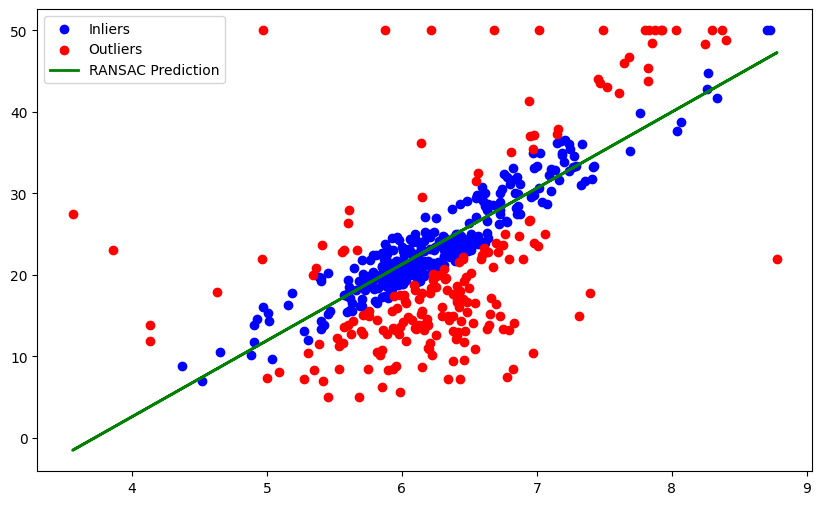

In [145]:
plt.figure(figsize=(10, 6))
plt.scatter(X[inliers], y[inliers], color='blue', label='Inliers')
plt.scatter(X[outliers], y[outliers], color='red', label='Outliers')
plt.plot(X, ypred, color='green', linewidth=2, label='RANSAC Prediction')
plt.legend()
plt.show()

### Linear Regression with all feature

In [146]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [147]:
data = pd.read_csv('../dataset/housing.data', header=None, sep='\\s+')

In [148]:
col_name = ['CRIM', 'ZN' , 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 
'PTRATIO', 'B', 'LSTAT', 'MEDV']
data.columns = col_name

In [149]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006,18.000,2.310,0,0.538,6.575,65.200,4.090,1,296.000,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0,0.469,6.421,78.900,4.967,2,242.000,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0,0.469,7.185,61.100,4.967,2,242.000,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0,0.458,6.998,45.800,6.062,3,222.000,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0,0.458,7.147,54.200,6.062,3,222.000,18.700,396.900,5.330,36.200


In [150]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [152]:
LR = LinearRegression()
LR.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [153]:
y_pred = LR.predict(X_test)

In [154]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 24.291119474973478
R^2 Score: 0.6687594935356326


In [155]:
for name, coef in zip(data.columns, map(lambda x: round(x, 2), LR.coef_)):
    print(f"{name}: {coef}")

print(f"Intercept: {round(LR.intercept_, 2)}")

CRIM: -0.11
ZN: 0.03
INDUS: 0.04
CHAS: 2.78
NOX: -17.2
RM: 4.44
AGE: -0.01
DIS: -1.45
RAD: 0.26
TAX: -0.01
PTRATIO: -0.92
B: 0.01
LSTAT: -0.51
Intercept: 30.25
